<a href="https://colab.research.google.com/github/springboardmentor12233a-tech/Ai_CliniScan/blob/gudla_sai_ganesh/CliniScanAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!cp /content/drive/MyDrive/CliniScan/CliniScan_images.zip /content/
!cp /content/drive/MyDrive/CliniScan/CliniScan_labels.zip /content/

In [3]:
!unzip -q CliniScan_images.zip
!unzip -q CliniScan_labels.zip

In [4]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'kaggle', 'CliniScan_images.zip', 'CliniScan_labels.zip', 'sample_data']


In [5]:
!pip install ultralytics opencv-python pandas numpy matplotlib albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00


In [6]:
IMG_PATH = "/content/kaggle/working/CliniScan/images"
LABEL_PATH = "/content/kaggle/working/CliniScan/labels"

print("Total Images:", len(os.listdir(IMG_PATH)))
print("Total Labels:", len(os.listdir(LABEL_PATH)))

Total Images: 15000
Total Labels: 15000


In [7]:
import os

for file in os.listdir(LABEL_PATH):
    path = os.path.join(LABEL_PATH, file)
    if os.path.getsize(path) > 0:
        with open(path, "r") as f:
            print(f.read())
        break

6 0.9443359375 0.802734375 0.529296875 0.67578125
13 2.10498046875 0.53466796875 0.1689453125 0.1650390625
11 1.13916015625 0.64794921875 0.2470703125 0.4130859375
13 0.9033203125 0.76171875 0.5625 0.48046875
7 2.09912109375 0.5244140625 0.1767578125 0.1875
11 2.09912109375 0.5244140625 0.1767578125 0.1875
11 1.1357421875 0.39306640625 0.40625 0.2626953125
0 1.5654296875 0.86767578125 0.314453125 0.4560546875
13 0.8798828125 0.72021484375 0.36328125 0.5654296875
6 2.0810546875 0.55224609375 0.138671875 0.1748046875
13 0.9443359375 0.802734375 0.529296875 0.67578125



In [8]:
import cv2

bad_images = []

for img_file in os.listdir(IMG_PATH):
    img_path = os.path.join(IMG_PATH, img_file)
    img = cv2.imread(img_path)
    if img is None:
        bad_images.append(img_file)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


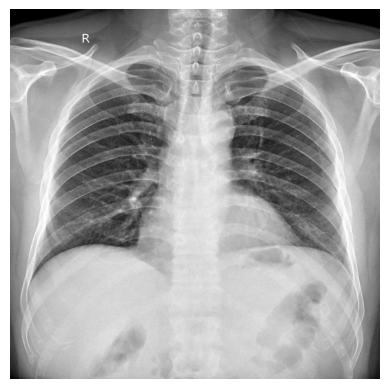

In [9]:
import random

sample_img = random.choice(os.listdir(IMG_PATH))
img_path = os.path.join(IMG_PATH, sample_img)
label_path = os.path.join(LABEL_PATH, sample_img.replace(".jpg", ".txt"))

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

if os.path.exists(label_path):
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.split())

        x_center *= w
        y_center *= h
        width *= w
        height *= h

        x_min = int(x_center - width/2)
        y_min = int(y_center - height/2)
        x_max = int(x_center + width/2)
        y_max = int(y_center + height/2)

        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255,0,0), 2)

plt.imshow(img)
plt.axis("off")
plt.show()

# Data Split

In [10]:
import os
import random
import shutil

BASE_PATH = "/content/CliniScan"
os.makedirs(BASE_PATH + "/images/train", exist_ok=True)
os.makedirs(BASE_PATH + "/images/val", exist_ok=True)
os.makedirs(BASE_PATH + "/labels/train", exist_ok=True)
os.makedirs(BASE_PATH + "/labels/val", exist_ok=True)

images = os.listdir(IMG_PATH)
random.shuffle(images)

split = int(0.8 * len(images))

train_imgs = images[:split]
val_imgs = images[split:]

for img in train_imgs:
    shutil.move(os.path.join(IMG_PATH, img), BASE_PATH + "/images/train/" + img)
    shutil.move(os.path.join(LABEL_PATH, img.replace(".jpg", ".txt")), BASE_PATH + "/labels/train/" + img.replace(".jpg", ".txt"))

for img in val_imgs:
    shutil.move(os.path.join(IMG_PATH, img), BASE_PATH + "/images/val/" + img)
    shutil.move(os.path.join(LABEL_PATH, img.replace(".jpg", ".txt")), BASE_PATH + "/labels/val/" + img.replace(".jpg", ".txt"))

print("Dataset split complete.")

Dataset split complete.


In [11]:
class_names = [
    "Aortic enlargement",
    "Atelectasis",
    "Calcification",
    "Cardiomegaly",
    "Consolidation",
    "ILD",
    "Infiltration",
    "Lung Opacity",
    "Nodule/Mass",
    "Other lesion",
    "Pleural effusion",
    "Pleural thickening",
    "Pneumothorax",
    "Pulmonary fibrosis"
]

yaml_content = f"""
path: /content/CliniScan
train: images/train
val: images/val

names:
"""

for i, name in enumerate(class_names):
    yaml_content += f"  {i}: {name}\n"

with open("/content/CliniScan/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created.")

data.yaml created.
